1. Import các gói có liên quan và bộ dữ liệu FMNIST

In [10]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets

data_folder = str(Path("archive").resolve())
print("Data folder:", data_folder)

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

Data folder: C:\Users\nthie\Downloads\Nhập môn phân tích dữ liệu học sâu\Nhap-mon-phan-tich-du-lieu-hoc-sau\Data-Analysis-Deep-Learning-Explanation\Week 9\archive


2. Xây dựng một lớp tìm nạp tập dữ liệu. Chúng ta cần ba hàm __init__, __getitem__ và
__len__:


In [11]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)


2b. Thêm phiên bản chuẩn hóa dữ liệu đầu vào (chia 255) mà không thay đổi lớp gốc:

In [12]:
class FMNISTDatasetNormalized(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

def get_data_normalized():
    train = FMNISTDatasetNormalized(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

3. Tạo một hàm tạo DataLoader – trn_dl từ tập dữ liệu – được gọi là FMNISTDataset. Điều này
sẽ lấy mẫu 32 ảnh ngẫu nhiên  cho kích thước bó:

In [13]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

4. Xác định một mô hình, cũng như hàm sai số và trình tối ưu hóa:

In [14]:
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
        ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
tr_images = fmnist.data
tr_targets = fmnist.targets

5. Xác định hàm sẽ huấn luyện tập dữ liệu trên một loạt hình ảnh:

In [15]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

6. Xây dựng hàm tính toán độ chính xác của tập dữ liệu nhất định:

In [16]:
# since there's no need for updating weights,
# we might as well not compute the gradients.
# Using this '@' decorator on top of functions
# will disable gradient computation in the entire function
@torch.no_grad()
def accuracy(x, y, model):
    model.eval() # <- let's wait till we get to dropout section
    # get the prediction matrix for a tensor of `x` images
    prediction = model(x)
    # compute if the location of maximum in each row coincides
    # with ground truth
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

7. Huấn luyện mạng nơ-ron bằng cách sử dụng các đoạn code sau:

Epoch 1/20
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20


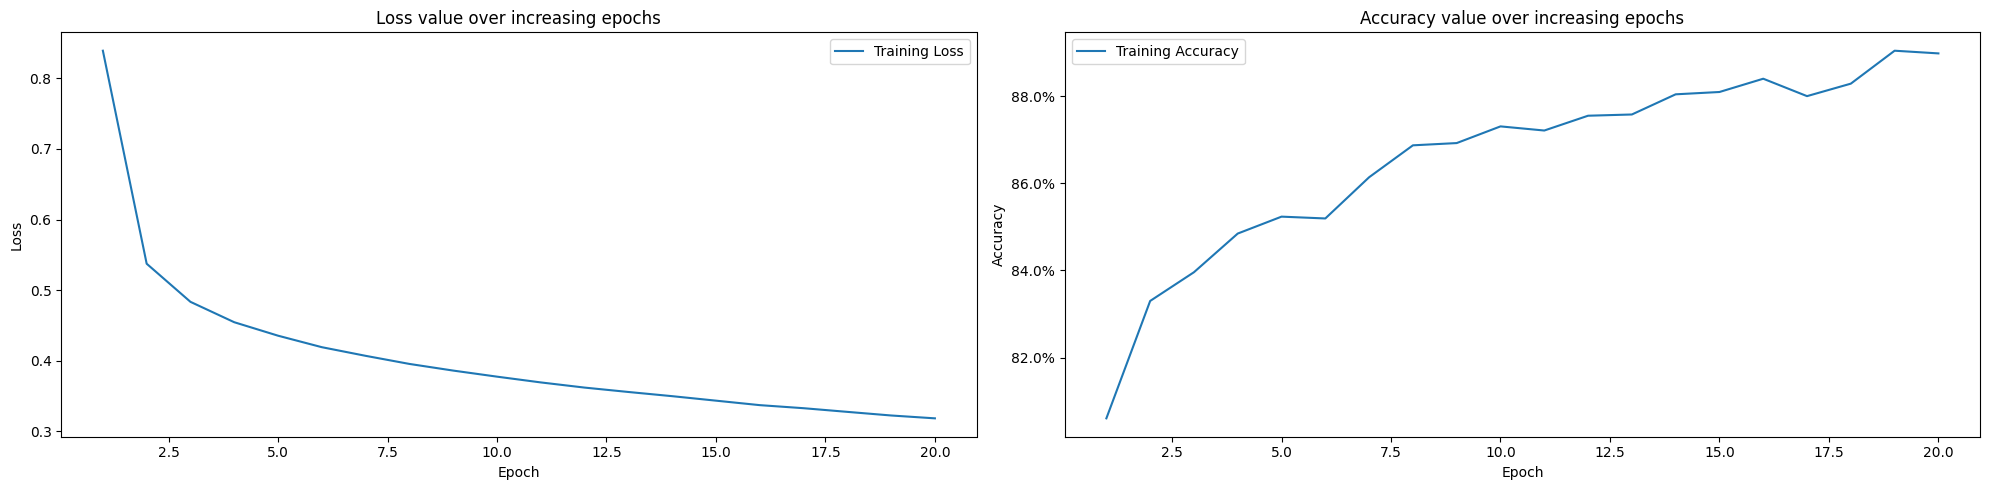

In [17]:
from matplotlib.ticker import PercentFormatter

trn_dl = get_data_normalized()
model, loss_fn, optimizer = get_model()
losses, accuracies = [], []

for epoch in range(20):
    print(f"Epoch {epoch + 1}/20")
    epoch_losses, epoch_accuracies = [], []

    for x, y in trn_dl:
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    epoch_loss = np.mean(epoch_losses)

    for x, y in trn_dl:
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

epochs = np.arange(1, 21)
plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(122)
plt.title("Accuracy value over increasing epochs")
plt.plot(epochs, accuracies, label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

plt.tight_layout()

8. Lưu và nạp mô hình sau khi huấn luyện:

In [18]:
from pathlib import Path

# Tao thu muc luu model neu chua ton tai
save_dir = Path("checkpoints")
save_dir.mkdir(parents=True, exist_ok=True)

# 1) Luu trong so (khuyen dung)
weights_path = save_dir / "fmnist_mlp_weights.pth"
torch.save(model.state_dict(), weights_path)
print("Da luu weights tai:", weights_path.resolve())

# 2) (Tuy chon) Luu ca model + optimizer + lich su train de co the train tiep
ckpt_path = save_dir / "fmnist_mlp_checkpoint.pth"
torch.save({
    "epoch": len(losses),
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "losses": losses,
    "accuracies": accuracies,
}, ckpt_path)
print("Da luu checkpoint tai:", ckpt_path.resolve())

# 3) Nap lai de suy luan
loaded_model, _, _ = get_model()
loaded_model.load_state_dict(torch.load(weights_path, map_location=device))
loaded_model.eval()
print("Nap model thanh cong va san sang predict.")

Da luu weights tai: C:\Users\nthie\Downloads\Nhập môn phân tích dữ liệu học sâu\Nhap-mon-phan-tich-du-lieu-hoc-sau\Data-Analysis-Deep-Learning-Explanation\Week 9\checkpoints\fmnist_mlp_weights.pth
Da luu checkpoint tai: C:\Users\nthie\Downloads\Nhập môn phân tích dữ liệu học sâu\Nhap-mon-phan-tich-du-lieu-hoc-sau\Data-Analysis-Deep-Learning-Explanation\Week 9\checkpoints\fmnist_mlp_checkpoint.pth
Nap model thanh cong va san sang predict.
